In [1]:
import xradar as xd
import sys
import wradlib as wrl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import cmap
from scipy.ndimage import (
    median_filter,
    gaussian_filter,
    generic_filter,
    uniform_filter,
    label,
)
from scipy.spatial import cKDTree
from pyproj import Transformer
import rioxarray
from collections import OrderedDict

In [2]:
# PLOTERS
###############################################################################

def plot_features(ax):
    departments = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='10m',
        edgecolor='black',
        facecolor='never',
        linewidth=0.6,
        linestyle='-'
    )
    ax.add_feature(departments, zorder=3)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5)
    # Optional: add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

In [3]:
# HELPERS
###############################################################################

def texture_std(x):

    valid = np.isfinite(x)

    if np.sum(valid) < 3:
        return np.nan

    return np.nanstd(x)

def compute_texture(field, size=(1, 5)):
    """
    Compute local texture of a radar field.
    """

    arr = field.values.copy()

    tex = generic_filter(
        arr,
        texture_std,
        size=size,
        mode="nearest"
    )

    return xr.DataArray(
        tex,
        dims=field.dims,
        coords=field.coords
    )

In [4]:

METEO_TABLE = {
    0 : "No data available",
    1 : "Non-meteorological target",
    2 : "Rain",
    3 : "Wet Snow",
    4 : "Snow",
    5 : "Graupel",
    6 : "Hail",
    7 : "Unused",
}

PRECIP_TABLE = {
    0 : "No data available",
    1 : "Ground clutter / anomalous propagation",
    2 : "Bio scatter",
    3 : "Precipitation",
    4 : "Large drops",
    5 : "Light precipitation",
    6 : "Moderate precipitation",
    7 : "Heavy precipitation",
}

CELL_TABLE = {
    0 : "Stratiform",
    1 : "Convection",
    2 : "Unused",
    3 : "Forbidden",
}

def decode_hclass(byte_val: int) -> tuple:
    if byte_val == 0:  # Reserved value for 'No Data'
        return (-2, -2, -2)
    if byte_val == 255:  # Reserved value for 'Area not scanned'
        return (np.nan, np.nan, np.nan)

    meteo_code = (byte_val >> 5) & 0x07
    precip_code = (byte_val >> 2) & 0x07
    cell_code = byte_val & 0x03

    return (meteo_code, precip_code, cell_code)

def decode_hclass_vect(raw_data: np.ndarray) -> np.ndarray:
    """Vectorized wrapper to decode an entire field."""
    return np.vectorize(decode_hclass, otypes=[object])(raw_data)

def get_(i, da):
    get = np.vectorize(lambda t: t[i])
    return xr.apply_ufunc(get, da)
#----------------------------------------------------------------------------------------

def open_iris_odict(filepath,load_data : bool = True, rawdata : bool =False, debug : bool =False):
    """
    Aquest funció només té raó d'ésser si wrl.io.iris.read_iris() no és capaç de decodificar la variable hclass.
    hclass conté un byte (8bits) que guarda la informació relativa a 3 classificadors
    """
    
    data_odict = wrl.io.iris.read_iris(
        filename=filepath,
        load_data=load_data,
        rawdata=rawdata,
        debug=debug,
    )
    return data_odict

def open_iris_dtree(filepath, decode_hclasse : bool = True):
    """
    Aquest funció només té raó d'ésser si open_iris_datatree() no és capaç de decodificar la variable hclass.
    hclass conté un byte (8bits) que guarda la informació relativa a 3 classificadors
    """
    dt = xd.io.open_iris_datatree(filepath)
    
    if decode_hclass:
        dt["/sweep_0"]["DB_HCLASS"].values = decode_hclass_vect(dt["/sweep_0"]["DB_HCLASS"].values)
        dt["/sweep_0"]["DB_HCLASS_meteor"] = get_(0, dt["/sweep_0"]["DB_HCLASS"])
        dt["/sweep_0"]["DB_HCLASS_precip"] = get_(1, dt["/sweep_0"]["DB_HCLASS"])
        dt["/sweep_0"]["DB_HCLASS_storm"]  = get_(2, dt["/sweep_0"]["DB_HCLASS"])

    return dt

In [5]:
filepath = "data/raw/Tablazo/2024/10/21/TAB241021234529.RAWWL5Y"
dtree = open_iris_dtree(filepath)

swp = dtree["/sweep_0"]
print(swp)

<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:            (sweep: 1, azimuth: 354, range: 664)
    Coordinates:
      * azimuth            (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
        elevation          (azimuth) float32 1kB ...
        time               (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.51500...
      * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
        longitude          float64 8B ...
        latitude           float64 8B ...
        altitude           float64 8B ...
    Dimensions without coordinates: sweep
    Data variables: (12/17)
        DBTH               (azimuth, range) float32 940kB ...
        DBZH               (azimuth, range) float32 940kB ...
        VRADH              (azimuth, range) float32 940kB ...
        WRADH              (azimuth, range) float32 940kB ...
        ZDR                (azimuth, range) float32 940kB ...
        KDP                (azimuth, range) float32 940kB ...
 

In [6]:
radar_alt = float(dtree["/"]["altitude"].values)
radar_lon = float(dtree["/"]["longitude"].values)
radar_lat = float(dtree["/"]["latitude"].values)

site = (radar_lon, radar_lat, radar_alt)

azimuth   = swp["azimuth"].data
range     = swp["range"].data
elangle   = swp["elevation"].data

elangle = dtree.sweep_fixed_angle.values
print(elangle)

azimuth_2d, range_2d = np.meshgrid(azimuth, range, indexing='ij')
elevation_2d = np.broadcast_to(elangle[:,np.newaxis], azimuth_2d.shape)

xyz,aeqd = wrl.georef.polar.spherical_to_xyz(
    range_2d,
    azimuth_2d,
    elevation_2d,
    site,
)

x = xyz[...,0]
y = xyz[...,1]
z = xyz[...,2]

transformer = Transformer.from_crs(
    aeqd,
    "EPSG:4326",
    always_xy=True,
)
lon,lat = transformer.transform(x,y)
alt = z

radar_lon = np.squeeze(lon)
radar_lat = np.squeeze(lat)
radar_z = np.squeeze(z)

swp.coords["gate_latitude"] = (('azimuth', 'range'), radar_lat)
swp.coords["gate_longitude"] = (('azimuth', 'range'), radar_lon)
swp.coords["gate_height"] = (('azimuth', 'range'), radar_z)

print(dtree)
print(swp.data_vars)

[0.5]
<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2024-10-21T23:45:30Z'
│       time_coverage_end    <U20 80B '2024-10-21T23:45:54Z'
│       longitude            float64 8B -74.2
│       altitude             float64 8B 3.544e+03
│       latitude             float64 8B 5.012
│       sweep_group_name     (sweep) int64 8B 1
│       sweep_fixed_angle    (sweep) float64 8B 0.5
│   Attributes:
│       Conventions:      None
│       instrument_name:  Tablazo, Radar
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet
│       history:          None
│       comment:          AEROCIVIL OPERATIONAL DUAL POLE SCAN
│       scan_name:        SURV_H

In [7]:
alpha=0.01
rhohv_thresh=0.85
snr_thresh=8.5
ncp_thresh=0.3
texture_thresh=20
zdr_thresh=7

In [8]:
###########################################################################
# VARIABLES
###########################################################################
DBZH = swp["DBZH"]
PHIDP = swp["PHIDP"]
KDP = swp["KDP"]
RHOHV = swp["RHOHV"]
ZDR = swp["ZDR"]


In [9]:
###########################################################################
# 1. METEOROLOGICAL MASK
###########################################################################

#met_mask = (
#      (RHOHV > rhohv_thresh)
#    & (SNR > snr_thresh)
#    #& (NCP > ncp_thresh) 
#    & (DBZH > 5)
#)

In [10]:

# 1. RECUPERAR LES MATRIUS DES DEL TEU SWEEP
# Assegura't que els noms coincideixen amb les variables de dades del teu DataTree
zh_db = DBZH.values     # Reflectivitat horitzontal en dBZ
zdr_db = ZDR.values    # Reflectivitat diferencial en dB
rhohv = RHOHV.values    # Coeficient de correlació creuada (0 a 1)

# 2. CALCULAR ELS COMPONENTS EN ESCALA LINEAL DE L'EQUACIÓ DE KILAMBI
# Transformació de dB a lineal de ZDR i de l'arrel quadrada (ZDR^0.5)
zdr_linear = 10.0 ** (zdr_db / 10.0)
zdr_sqrt_linear = 10.0 ** (zdr_db / 20.0)

# 3. EXECUTAR L'EQUACIÓ COMPLETA DEL DR
# Calculem el numerador i el denominador de la ràtio de despolarització
numerador = zdr_linear + 1.0 - (2.0 * zdr_sqrt_linear * rhohv)
denominador = zdr_linear + 1.0 + (2.0 * zdr_sqrt_linear * rhohv)

# Evitar divisions per zero si el denominador és nul o invàlid
with np.errstate(divide='ignore', invalid='ignore'):
    dr_linear = numerador / denominador
    # El paper finalment passa el resultat a escala logarítmica (dB)
    dr_db = 10.0 * np.log10(dr_linear)

# Substituir potencials valors infinits o nuls per un valor neutre baix
# dr_db = np.nan_to_num(dr_db, nan=99.0, posinf=99.0, neginf=99.0)

# ==========================================================
# 4. APLICAR ELS LLINDARS DE TALL DEL PAPER (HARD MASKING)
# ==========================================================
# Segons Kilambi et al. (2018), els hidrometeors (pluja real) tenen valors 
# de DR molt baixos (normalment inferiors a -12 dB o -15 dB).
# Els insectes, clutter i soroll urbà solen tenir valors de DR superiors a -10 dB.

# Creem la màscara dura (True = Esborrar cel·la per no-meteorològica)
llindar_tall = -12.0
mascara_meteo = dr_db < llindar_tall

# 5. INTEGRAR LA NOVA VARIABLE AL TEU DATATREE
swp["DR"] = xr.DataArray(dr_db, dims=["azimuth","range"])
swp["DR"].attrs["long_name"] = "Dual-Polarization Depolarization Ratio"
swp["DR"].attrs["units"] = "dB"

print("Variable DR calculada amb èxit!")
print(f"Cel·les detectades com a soroll/insectes (DR > {llindar_tall} dB): {np.sum(~mascara_meteo)}")

Variable DR calculada amb èxit!
Cel·les detectades com a soroll/insectes (DR > -12.0 dB): 216917


/home/cpmunoz/miniconda3/envs/radar-env/lib/python3.14/site-packages/xradar/io/backends/iris.py:253: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(decode_array(data, **kwargs))


In [11]:
DR = swp["DR"]
met_mask = (
      (DR < llindar_tall)
)

In [12]:
###########################################################################
# 2. REMOVE ISOLATED PIXELS
###########################################################################

#density = uniform_filter(
#    met_mask.astype(float),
#    size=(3,5)
#)

#met_mask = density > 0.5

mask_vals = met_mask.values.copy()

labels, num = label(mask_vals)

sizes = np.bincount(labels.ravel())

min_size = 3

small = sizes < min_size

# Preserve background
small[0] = False

remove_mask = small[labels]

mask_vals[remove_mask] = False

met_mask = xr.DataArray(
    mask_vals,
    dims=met_mask.dims,
    coords=met_mask.coords
)

In [13]:
###########################################################################
# 5. PHIDP TEXTURE
###########################################################################

phidp = PHIDP

textura_phidp = wrl.util.texture(PHIDP.values)
textura_phidp = np.nan_to_num(textura_phidp, nan=0.0)

tPHIDP = xr.DataArray(
    textura_phidp,
    dims=phidp.dims,
    coords=phidp.coords
)

In [14]:
###########################################################################
# 6. PHIDP QUALITY MASK
###########################################################################

met_mask = (
    met_mask
    & (tPHIDP < texture_thresh)
)

In [15]:
###########################################################################
# 3. FILTER REFLECTIVITY
###########################################################################

cDBZH = xr.where(
    met_mask,
    DBZH,
    np.nan
)

In [16]:
###########################################################################
# 7. FILTERED PHIDP
###########################################################################

fPHIDP = xr.where(
    met_mask,
    PHIDP,
    np.nan
)

In [17]:
gate_latitude  = swp.coords["gate_latitude"].values
gate_longitude = swp.coords["gate_longitude"].values
gate_height    = swp.coords["gate_height"].values

In [18]:
import numpy as np
import rioxarray
from scipy.interpolate import interpn

dem_filepath = "10s090w_20101117_gmted_mea075.tif"

# 1. Carregar el DEM i extreure els vectors de l'eix X (longitud) i Y (latitud)
dem = rioxarray.open_rasterio(dem_filepath, mask_and_scale=True).squeeze()
dem_lon = dem.x.values
dem_lat = dem.y.values

# Si les latituds van de nord a sud (valors decreixents), invertim l'eix i la matriu 
# perquè interpn necessita obligatòriament vectors estrictament creixents
if dem_lat[0] > dem_lat[-1]:
    dem_lat = dem_lat[::-1]
    dem_values = dem.values[::-1, :]
else:
    dem_values = dem.values

# 2. Interpola directament sobre la teva malla polar del radar (en NumPy pur)
# Creem la llista de punts de destinació on vols extreure l'elevació
punts_radar = np.stack((gate_latitude, gate_longitude), axis=-1)

# Executem la interpolació lineal (fora dels límits del DEM assignarà un valor de 0.0)
terrain_height = interpn(
    (dem_lat, dem_lon), 
    dem_values, 
    punts_radar, 
    method="linear", 
    bounds_error=False, 
    fill_value=0.0
)

# 3. Eliminar qualsevol valor nul residual (NaN)
terrain_height = np.nan_to_num(terrain_height, nan=0.0)



In [19]:
beamwidth = 1.0

r_distances = swp.coords["range"].values

beamradius = wrl.util.half_power_radius(r_distances, beamwidth)

pbb = wrl.qual.beam_block_frac(terrain_height, gate_height, beamradius)
cbb = wrl.qual.cum_beam_block_frac(np.ma.masked_invalid(pbb))

cbb_clean = np.ma.filled(cbb, fill_value=0.0)

print(cbb_clean)

swp["CBB"] = xr.DataArray(cbb_clean, dims=["azimuth", "range"])

swp["CBB"].attrs["long_name"] = "Cumulative Beam Blockage Fraction"
swp["CBB"].attrs["units"] = "1"
swp["CBB"].attrs["comment"] = "Calculat usant DEM GMTED2010 a 250m"


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/home/cpmunoz/miniconda3/envs/radar-env/lib/python3.14/site-packages/wradlib/qual.py:181: RuntimeWarning: invalid value encountered in sqrt
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)
/home/cpmunoz/miniconda3/envs/radar-env/lib/python3.14/site-packages/wradlib/qual.py:181: RuntimeWarning: invalid value encountered in arcsin
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)


In [20]:
dbzh_original = cDBZH.values
cbb_data = swp["CBB"].values
print(cbb_data)

dbzh_corregit = np.copy(dbzh_original)

mask_compensar = (cbb_data >= 0.1) & (cbb_data <= 0.5)

dbzh_corregit[mask_compensar] = dbzh_corregit[mask_compensar] - 10.0 * np.log10(1.0 - cbb_data[mask_compensar])

mask_eliminar = cbb_data > 0.5
dbzh_corregit[mask_eliminar] = np.nan

DBZH_terrain_corrected = xr.DataArray(dbzh_corregit, dims=["azimuth", "range"])


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [21]:
############################################################################
## 4. INITIAL PHIDP SMOOTHING
############################################################################
## 1. interpolate gaps
#
#phidp = fPHIDP
#
#phidp = phidp.interpolate_na(
#    dim="range",
#    method="linear",
#    limit=10
#)
#
## 2. running median
#phidp_vals = median_filter(
#    phidp.values,
#    size=(1,5)
#)
#
#sPHIDP = xr.DataArray(
#    phidp_vals,
#    dims=phidp.dims,
#    coords=phidp.coords
#)
#
## 4. radial running mean
#sPHIDP = sPHIDP.rolling(
#    range=25,
#    center=True
#).mean()

In [22]:
############################################################################
## 8. FINAL PHIDP SMOOTHING
############################################################################
#
#vals = np.nan_to_num(
#    fPHIDP.values,
#    nan=0
#)
#
#vals = median_filter(
#    vals,
#    size=(1,5)
#)
#
#vals = gaussian_filter(
#    vals,
#    sigma=(0,1)
#)

In [23]:
# Suposem que 'fPHIDP' és el teu DataArray original amb els NaNs de la textura
phidp_inicial = fPHIDP.copy()

# ===========================================================================
# PAS 1: INTERPOLACIÓ GEOMÈTRICA DE BUITS (Justificació: Hubbert & Bringi, 1995)
# ===========================================================================
# Omplim els buits petits (fins a 10 cel·les) per mantenir la continuïtat del raig.
# Això evita que les vores de la pluja caiguin a zero de forma artificial.
phidp_interp = phidp_inicial.interpolate_na(
    dim="range",
    method="linear",
    limit=10
)

# ===========================================================================
# PAS 2: FILTRE DE MEDIANA EN 2D (Eliminació de soroll d'impuls / valors atípics)
# ===========================================================================
# Escaneja la matriu cel·la per cel·la aplicant una finestra radial de 5 píxels.
# S'executa en NumPy pur sobre els valors interpolats.
vals_mediana = median_filter(
    phidp_interp.values,
    size=(1, 5)
)

# Reconstruïm el DataArray per poder aplicar les funcions geomètriques de xarray
phidp_mediana = xr.DataArray(
    vals_mediana,
    dims=phidp_interp.dims,
    coords=phidp_interp.coords
)

# ===========================================================================
# PAS 3: MITJANA MÒBIL RADIAL ADAPTATIVA (Suavitzat final de la línia base)
# ===========================================================================
# Apliquem una finestra de 25 cel·les per homogeneïtzar la fase abans de derivar.
# SOLUCIÓ CRÍTICA: 'min_periods=1' impedeix que els NaNs grans (com muntanyes esborrades)
# es propaguin com una taca d'oli i destrueixin les zones de pluja neta.
sPHIDP = phidp_mediana.rolling(
    range=25,
    center=True,
    min_periods=1
).mean()

# ===========================================================================
# PAS 4: BLOCATGE DE SEGURETAT FINAL PER A WRADLIB (fillna)
# ===========================================================================
# L'algorisme de convolució de Lanczos de wradlib llançarà un error matemàtic
# si troba algun NaN residual a la matriu. Omplim els NaNs que hagin quedat
# (exclusivament a les zones de cel completament buit a la perifèria) amb 0.0.
sPHIDP_clean = sPHIDP.fillna(0.0)



In [24]:
# 1. Agafem la variable del pas anterior (el suavitzat adaptatiu)
vals = np.copy(sPHIDP_clean.values)

# ===========================================================================
# PAS 9: FORÇAT DE MONOTONICITAT (Justificació: Hubbert & Bringi, 1995)
# ===========================================================================
# Corregim cel·la per cel·la al llarg de cada raig d'azimut per assegurar 
# que la fase mai decreix i eliminem el risc de KDP negatiu.
for az in np.arange(vals.shape[0]):
    ray = vals[az]
    for i in np.arange(1, len(ray)):
        if np.isfinite(ray[i-1]) and np.isfinite(ray[i]):
            if ray[i] < ray[i-1]:
                ray[i] = ray[i-1]
    vals[az] = ray

# ===========================================================================
# PAS 10: FILTRES DE MEDIANA FINALS (Poliment de la línia creixent)
# ===========================================================================
# Apliquem la seqüència exacta de filtres de mediana del teu codi (mida 4 i 8)
# per eliminar qualsevol graó artificial generat pel bucle de monotonicitat.
vals = median_filter(vals, size=(1, 4))
vals = median_filter(vals, size=(1, 8))

# ===========================================================================
# PAS 11: RECONSTRUCCIÓ DE LA VARIABLE I MÀSCARA METEOROLÒGICA
# ===========================================================================
# Apliquem de forma estricta la teva màscara de control de qualitat (met_mask)
# per assegurar-nos que fora de les zones de pluja el mapa quedi net (NaN).
vals_with_nan = np.copy(vals)
vals_with_nan[~met_mask.values] = np.nan

sPHIDP = xr.DataArray(
    vals_with_nan,
    dims=fPHIDP.dims,
    coords=fPHIDP.coords
)

In [25]:
###########################################################################
# 10. CLEAN KDP
###########################################################################

cKDP = xr.where(
    met_mask,
    KDP,
    np.nan
)

In [26]:
###########################################################################
# 10.5. CREATE KDP FROM FILTERED PHIDP
###########################################################################
#dKDP = wrl.dp.kdp_from_phidp(
#    fPHIDP,
#    winlen=31,
#    method="lanczos_conv"
#)
#
#vals = median_filter(
#    dKDP.values,
#    size=(1,15)
#)
#
#vals = median_filter(
#    dKDP.values,
#    size=(1,25)
#)
#
#vals = median_filter(
#    dKDP.values,
#    size=(1,35)
#)
#dKDP = xr.DataArray(
#    vals,
#    dims=dKDP.dims,
#    coords=dKDP.coords
#)


In [27]:
r_metres = swp.coords["range"].values
resolucio_metres = r_metres[1] - r_metres[0]  # Això sol donar 62.5m o 125m segons el radar

# 2. CONVERTIR HO A QUILÒMETRES (Requisit físic del KDP)
dr_km = resolucio_metres / 1000.0
print(f"Resolució espacial del radar detectada: {resolucio_metres} metres ({dr_km} km)")
# ===========================================================================
# 1. CÀLCUL DEL KDP AMB LA FUNCIÓ OFICIAL DE WRADLIB
# ===========================================================================
# Enviem la matriu 'vals' (que prové del forçat de monotonicitat, 100% numèrica)
# Usem 'winlen=24' perquè és la longitud de finestra òptima per a la Banda X de Bogotà
# i el mètode 'lanczos_conv' que aplica una derivada de convolució d'alta precisió.
dKDP_calculat = wrl.dp.kdp_from_phidp(
    sPHIDP.values, 
    winlen=25,
    dr=dr_km,
    method="lanczos_conv"
)

# ===========================================================================
# 2. POST-NETEJA CRÍTICA (POST-PROCESSING) DEL KDP
# ===========================================================================

# --- Pas A: Eliminació de valors negatius artificials ---
# Per la física del radar, la fase només augmenta, per tant el KDP real ha de ser positiu.
# Els petits valors negatius són artefactes matemàtics de la convolució a les vores de la pluja.
# Els forcem a 0.0 de forma segura.
dKDP_net = np.where(dKDP_calculat < 0.0, 0.0, dKDP_calculat)

# --- Pas B: Filtre de Mediana final per homogeneïtzar els nuclis ---
# Apliquem un filtre de mediana suau radial (mida 3) per netejar qualsevol "pic elèctric" 
# o valor extrem aïllat generat durant la derivació numèrica.
dKDP_net = median_filter(dKDP_net, size=(1, 3))

# --- Pas C: Aplicació del Hard Masking de la màscara meteorològica ---
# Recuperem la teva màscara de control de qualitat (met_mask) per assegurar-nos que
# tot el cel buit, zones de soroll de fons o muntanyes severes quedin com a NaN.
dKDP_final = np.copy(dKDP_net)
dKDP_final[~met_mask.values] = np.nan

dKDP = xr.DataArray(
    dKDP_final,
    dims=cKDP.dims,
    coords=cKDP.coords,
)

Resolució espacial del radar detectada: 450.0 metres (0.44999998807907104 km)


In [30]:
###########################################################################
# 11. SPECIFIC ATTENUATION
###########################################################################

#A = alpha * cKDP
A = alpha * dKDP

###########################################################################
# 12. RANGE RESOLUTION
###########################################################################

dr = float(
    swp["range"][1] - swp["range"][0]
)

dr_km = dr / 1000.0

###########################################################################
# 13. PIA
###########################################################################

pia_vals = 2 * np.nancumsum(
    A.values * dr_km,
    axis=1
)

PIA = xr.DataArray(
    pia_vals,
    dims=A.dims,
    coords=A.coords
)

###########################################################################
# 14. ATTENUATION CORRECTED REFLECTIVITY
###########################################################################

cDBZH_attcorr = DBZH_terrain_corrected + PIA

###########################################################################
# 15. RAINFALL ESTIMATION
###########################################################################

# R(A)
R_A = 4120 * (A ** 1.03)

# R(KDP)
#R_KDP = 40.6 * (cKDP ** 0.85)
R_KDP = 160 * (dKDP ** 0.88)

R_Z = (10**(cDBZH_attcorr/10)/180)**(1/1.4)

In [31]:
swp["met_mask"] = met_mask

swp["sPHIDP"] = sPHIDP
swp["sPHIDP"].attrs["long_name"] = "Smoothed Phase Shift (PhiDP)"
swp["sPHIDP"].attrs["units"] = "degrees"

swp["tPHIDP"] = tPHIDP

swp["DBZH_terrain_corrected"] = DBZH_terrain_corrected
swp["DBZH_terrain_corrected"].attrs["long_name"] = "Reflectivity corrected for beam blockage"
swp["DBZH_terrain_corrected"].attrs["units"] = "dBZ"

swp["fPHIDP"] = fPHIDP

swp["cKDP"] = cKDP

swp["dKDP"] = dKDP

swp["A"] = A

swp["PIA"] = PIA

swp["cDBZH"] = cDBZH_attcorr

swp["R_A"] = R_A

swp["R_KDP"] = R_KDP

swp["R_Z"] = R_Z

In [32]:
number_of_colors = 30

In [33]:
var = "DBTH"

<xarray.DataArray 'DBTH' (azimuth: 354, range: 664)> Size: 940kB
[235056 values with dtype=float32]
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B ...
    latitude        float64 8B ...
    altitude        float64 8B ...
Attributes:
    standard_name:  radar_equivalent_reflectivity_factor_h
    units:          dBZ
    long_name:      Total power H (uncorrected reflectivity)


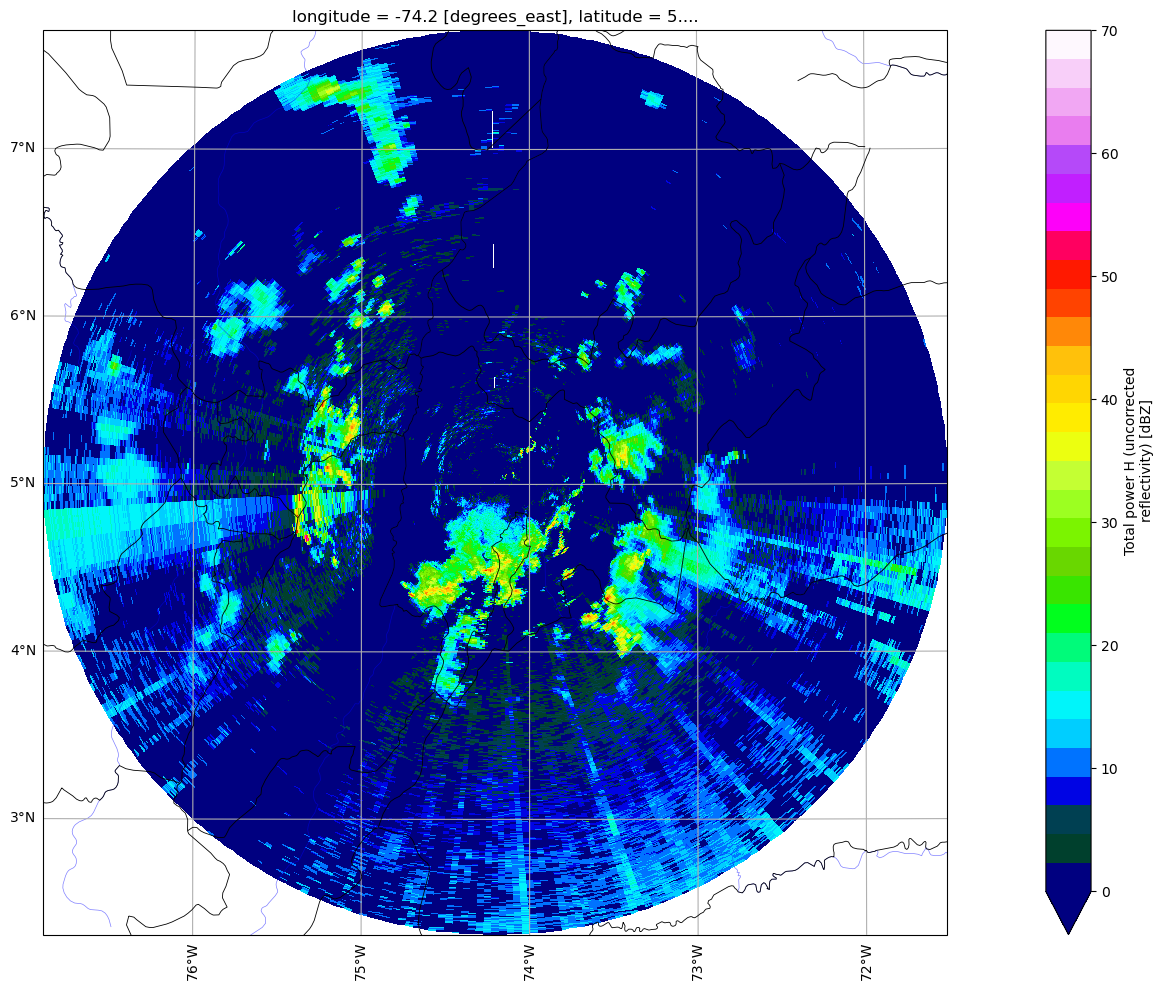

In [34]:
da = swp[f"{var}"]

print(da)


da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [35]:
var = "cDBZH"

<xarray.DataArray 'cDBZH' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B -74.2
    latitude        float64 8B 5.012
    altit

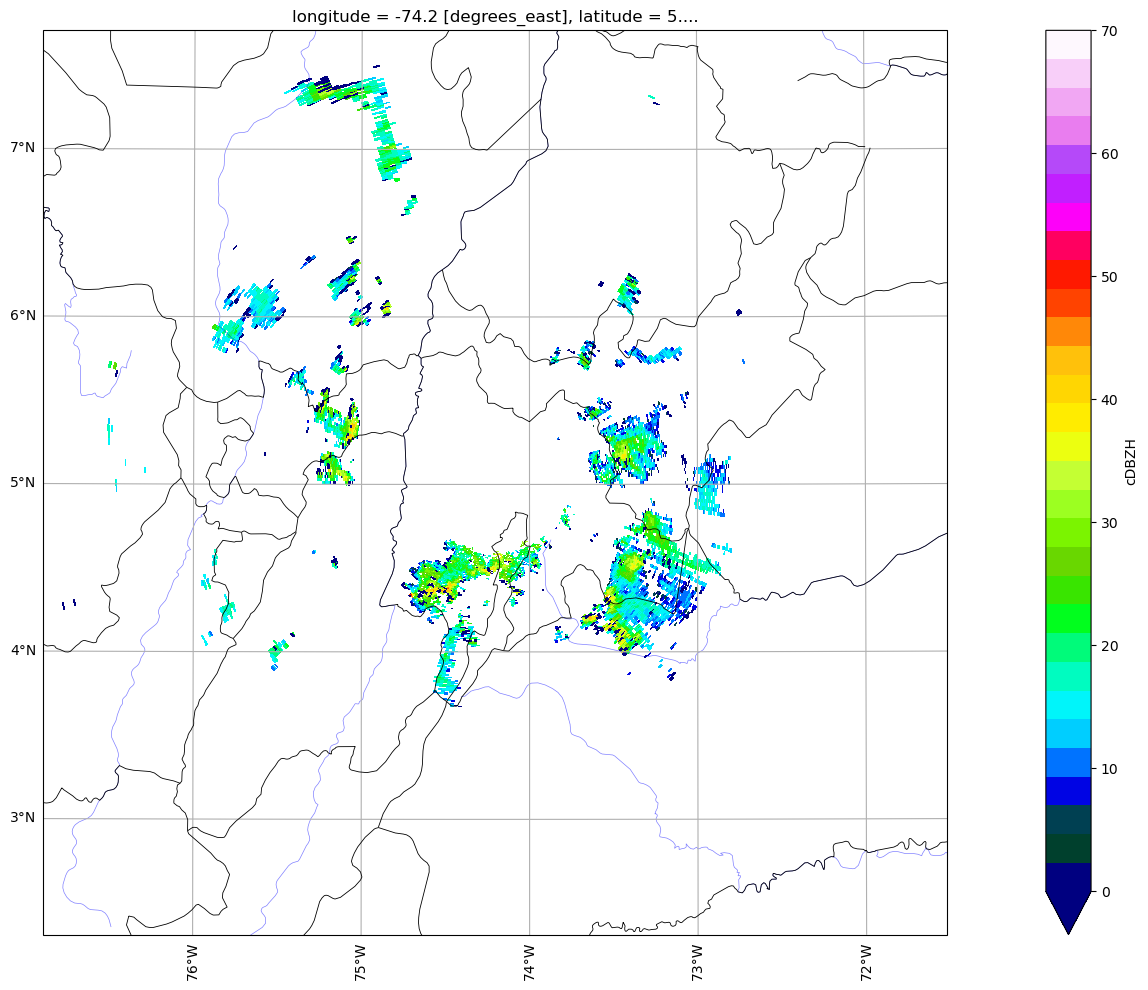

In [36]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [37]:
var = "ZDR"

<xarray.DataArray 'ZDR' (azimuth: 354, range: 664)> Size: 2MB
array([[-7.9375, -7.9375, -7.9375, ..., -8.    , -8.    , -8.    ],
       [-7.9375, -7.9375, -7.9375, ..., -8.    , -8.    , -8.    ],
       [-7.9375, -7.9375, -7.9375, ..., -8.    , -8.    , -8.    ],
       ...,
       [-7.9375, -7.9375, -7.9375, ..., -8.    , -8.    , -8.    ],
       [-7.9375, -7.9375, -7.9375, ..., -8.    , -8.    , -8.    ],
       [-7.9375, -7.9375, -7.9375, ..., -8.    , -8.    , -8.    ]],
      shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate

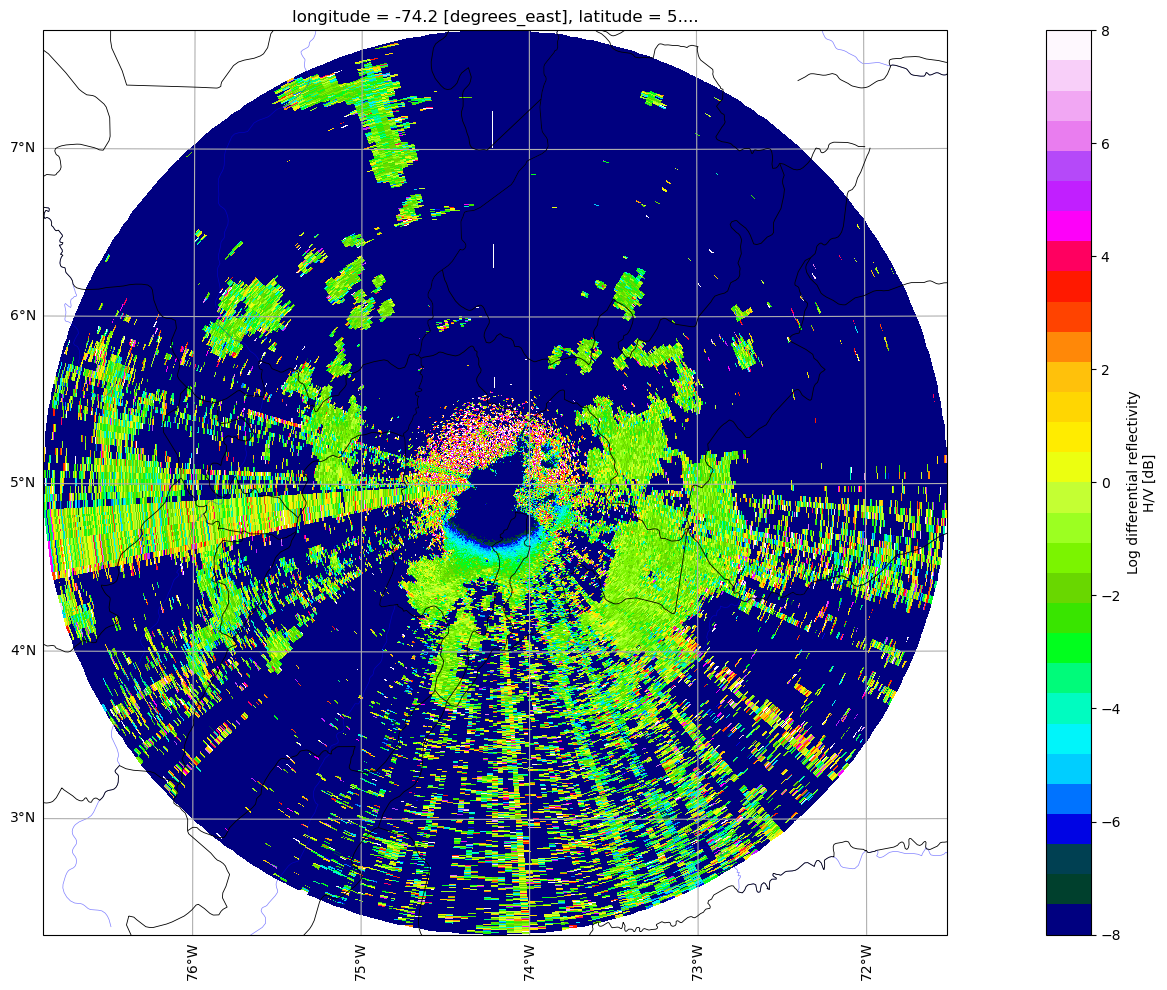

In [38]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [39]:
var = "PHIDP"

<xarray.DataArray 'PHIDP' (azimuth: 354, range: 664)> Size: 940kB
[235056 values with dtype=float32]
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B -74.2
    latitude        float64 8B 5.012
    altitude        float64 8B 3.544e+03
Attributes:
    standard_name:  radar_differential_phase_hv
    units:          degrees
    long_name:      Differential phase HV


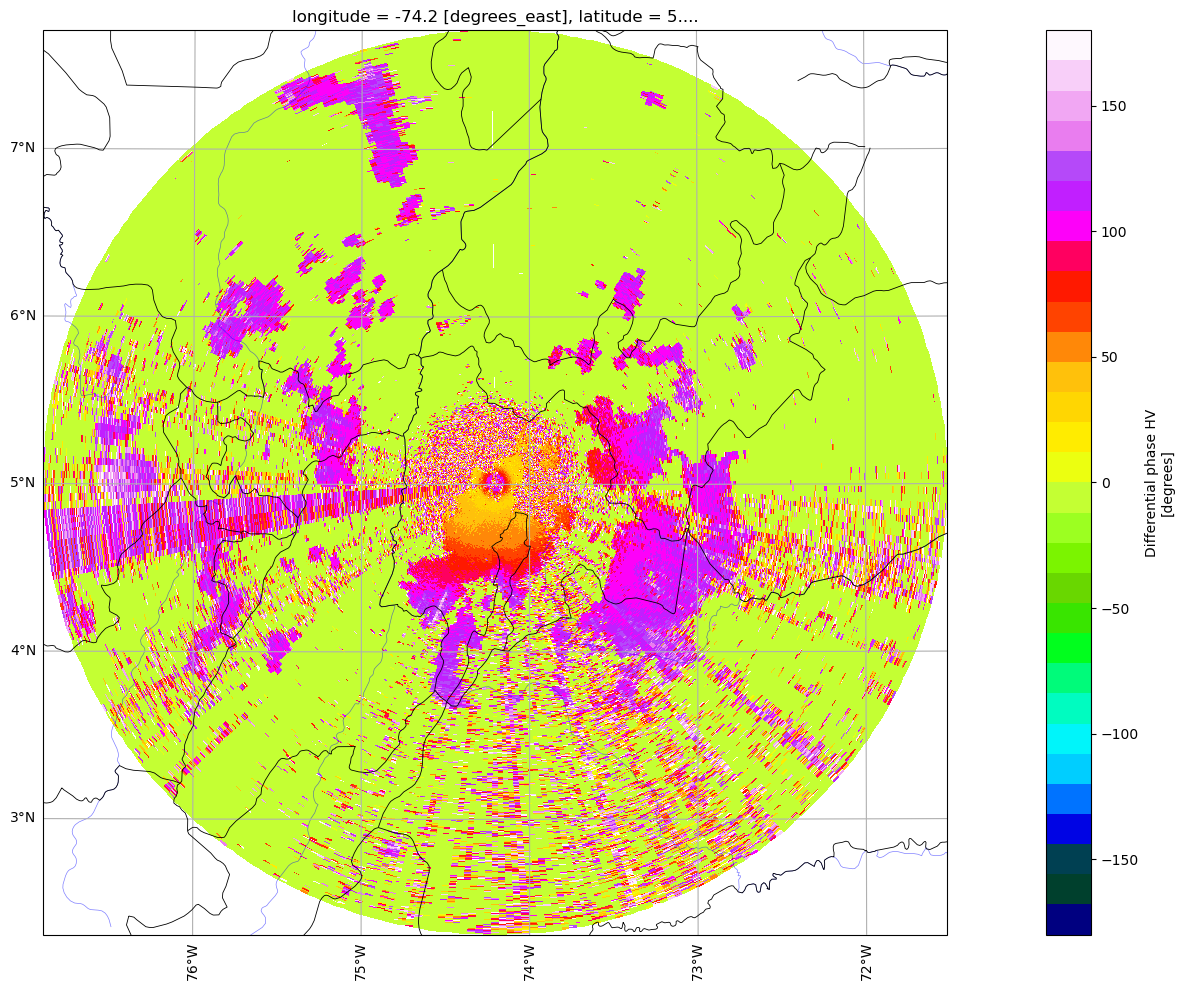

In [40]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [41]:
var = "tPHIDP"

<xarray.DataArray 'tPHIDP' (azimuth: 354, range: 664)> Size: 2MB
array([[62.0562466 , 74.15888635, 76.02355069, ...,  0.        ,
         0.        ,  0.        ],
       [78.34603727, 65.78872686, 17.74485925, ...,  0.        ,
         0.        ,  0.        ],
       [84.66531909, 86.86632499, 72.09911648, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [97.7356888 , 85.53252675, 74.90722143, ...,  0.        ,
        33.32310303, 42.15076172],
       [70.30978457, 72.00109856, 57.47097729, ...,  0.        ,
         0.        ,  0.        ],
       [80.6162713 , 72.34553264, 44.57742253, ...,  0.        ,
         0.        ,  0.        ]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0

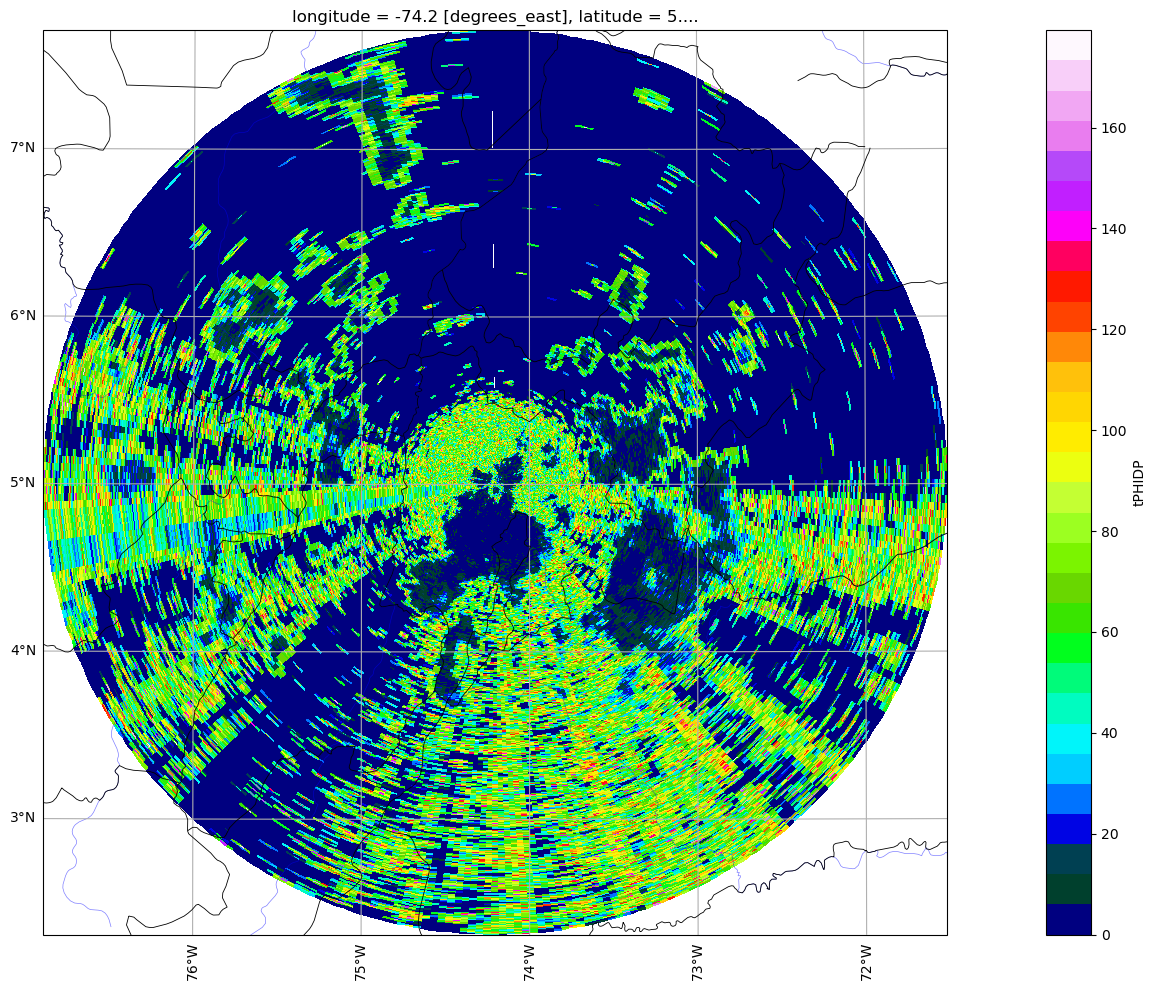

In [42]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [43]:
var = "sPHIDP"

<xarray.DataArray 'sPHIDP' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B -74.2
    latitude        float64 8B 5.012
    alti

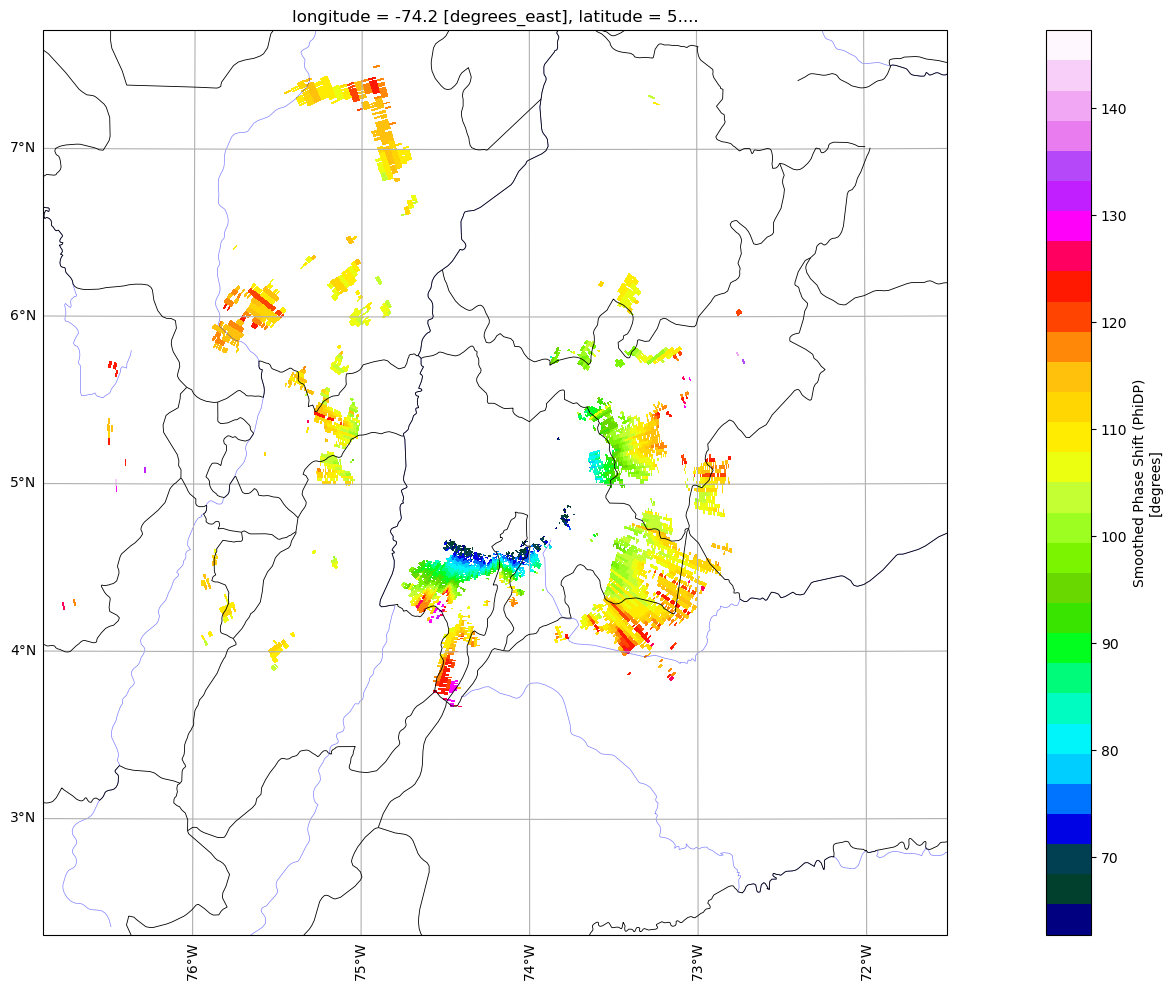

In [44]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [45]:
var = "DR"

<xarray.DataArray 'DR' (azimuth: 354, range: 664)> Size: 2MB
array([[-1.07250909, -1.20063331, -2.03265584, ...,         nan,
                nan,         nan],
       [-2.72713096, -3.58624996, -2.84405718, ...,         nan,
                nan,         nan],
       [-2.44898429,  0.        , -1.20063331, ...,         nan,
                nan,         nan],
       ...,
       [-3.7087797 , -0.37751132, -2.87274268, ...,         nan,
                nan,         nan],
       [-2.51284852, -0.92763912, -1.61913428, ...,         nan,
                nan,         nan],
       [-3.33353342, -2.51284852, -1.20063331, ...,         nan,
                nan,         nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ...

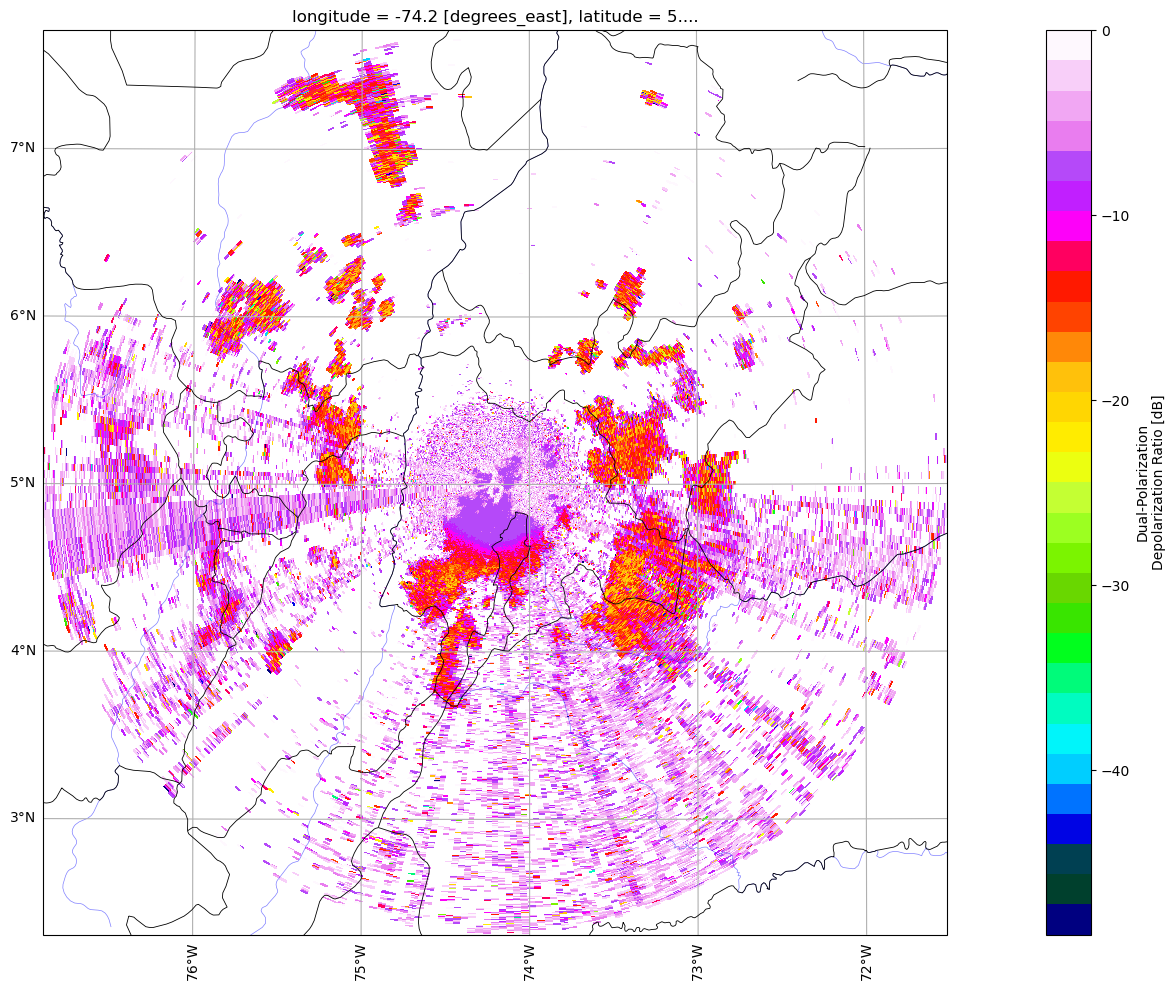

In [46]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmax=0,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()
plt.show()

In [47]:
var = "cKDP"

<xarray.DataArray 'cKDP' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B -74.2
    latitude        float64 8B 5.012
    altitu

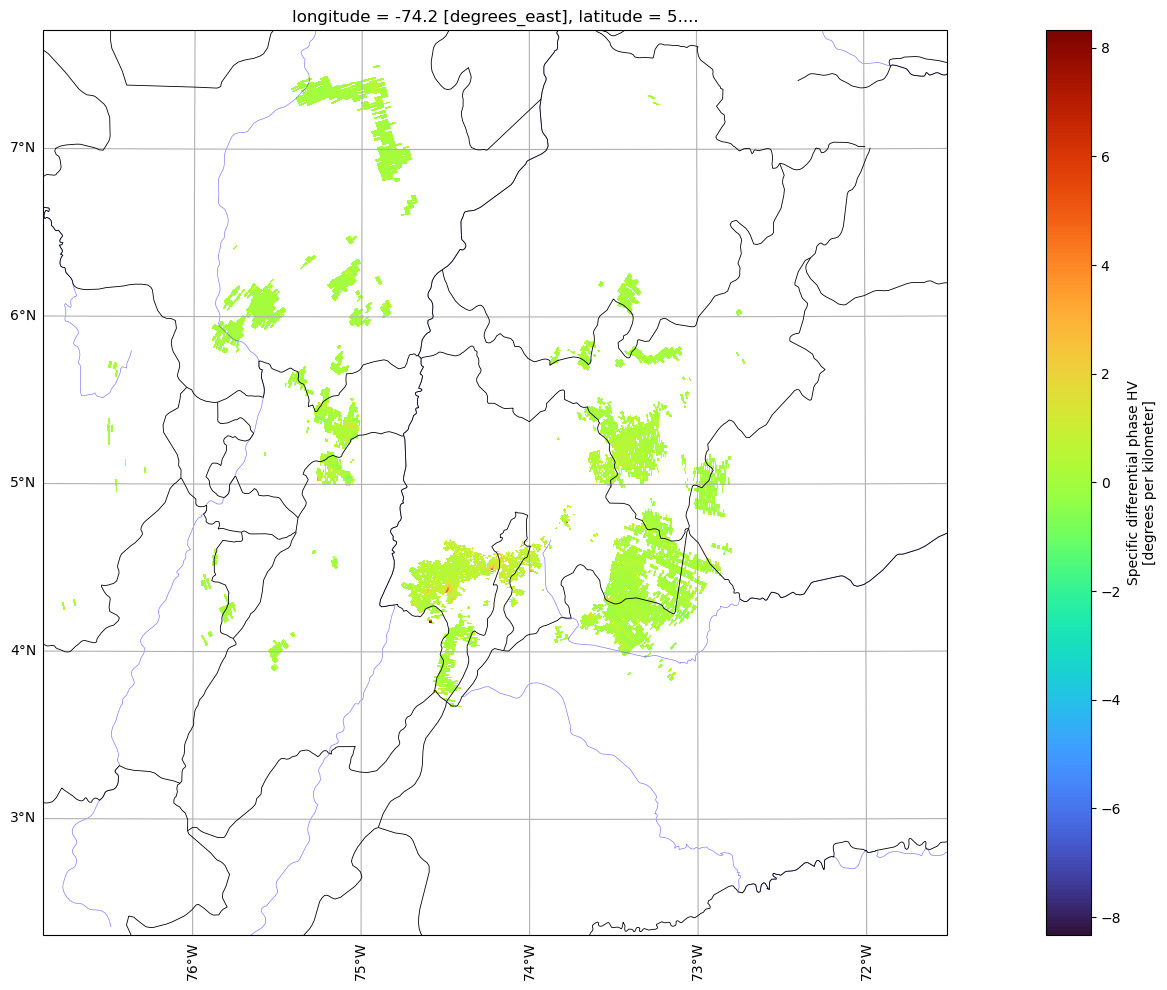

In [48]:
da = swp[f"{var}"]

print(da)
print(np.unique_values(da.values[~np.isnan(da.values)]))

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    #vmin=0,
    #vmax=3,
    cmap="turbo",
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [49]:
var = "dKDP"

<xarray.DataArray 'dKDP' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B -74.2
    latitude        float64 8B 5.012
    altitu

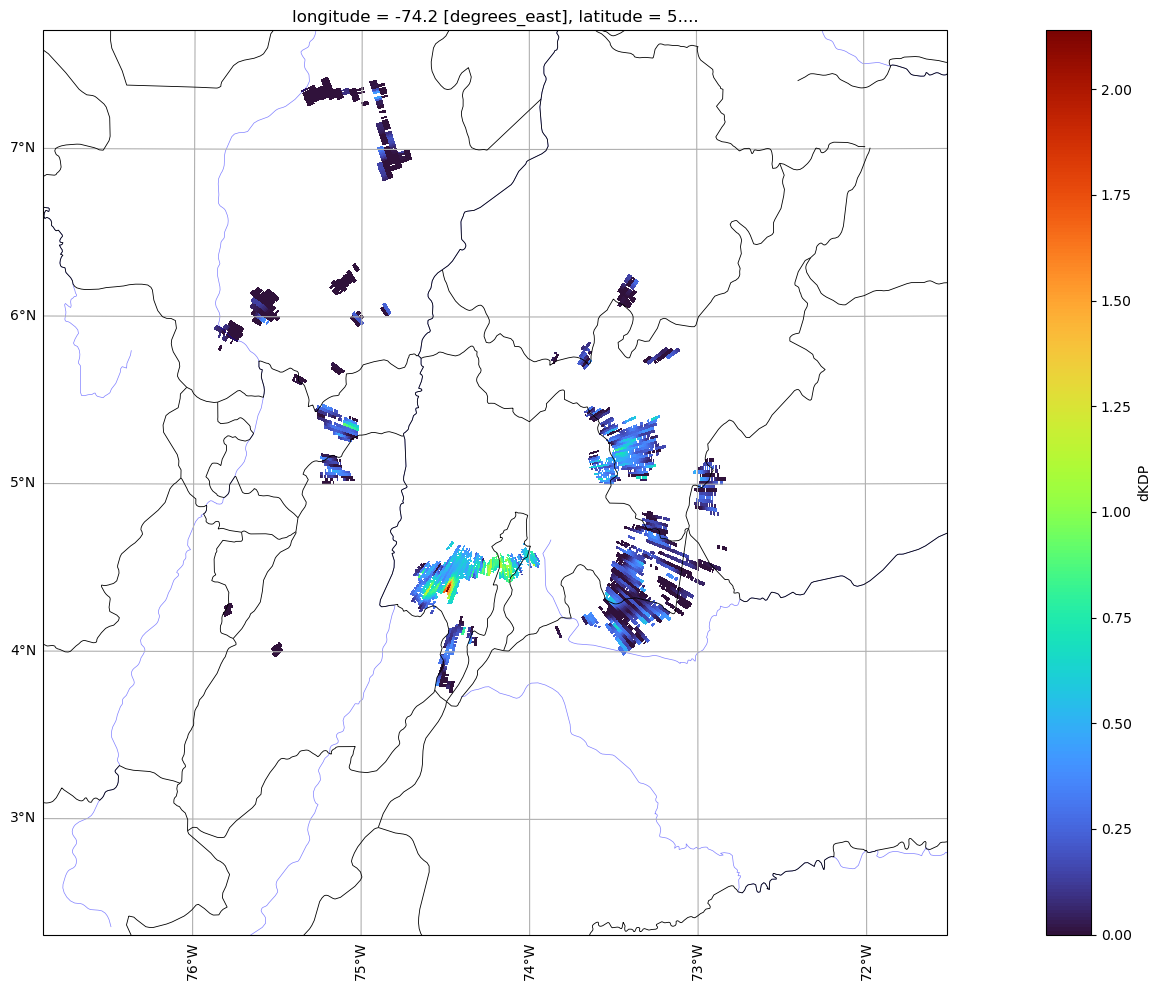

In [50]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)])[::100]:
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap="turbo",
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [51]:
var = "R_A"

<xarray.DataArray 'R_A' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B -74.2
    latitude        float64 8B 5.012
    altitud

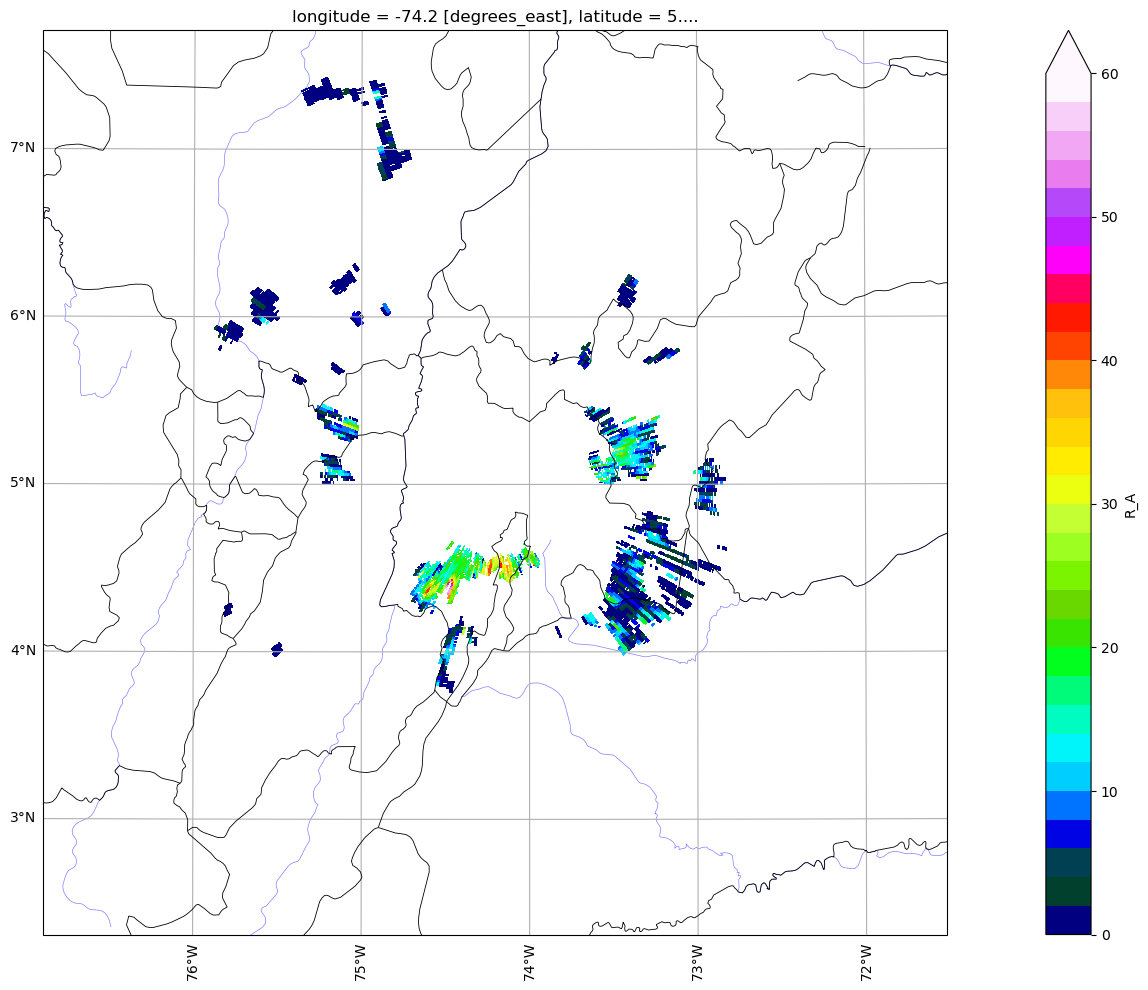

In [52]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)]):
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [53]:
var= "R_Z"

<xarray.DataArray 'R_Z' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B -74.2
    latitude        float64 8B 5.012
    altitud

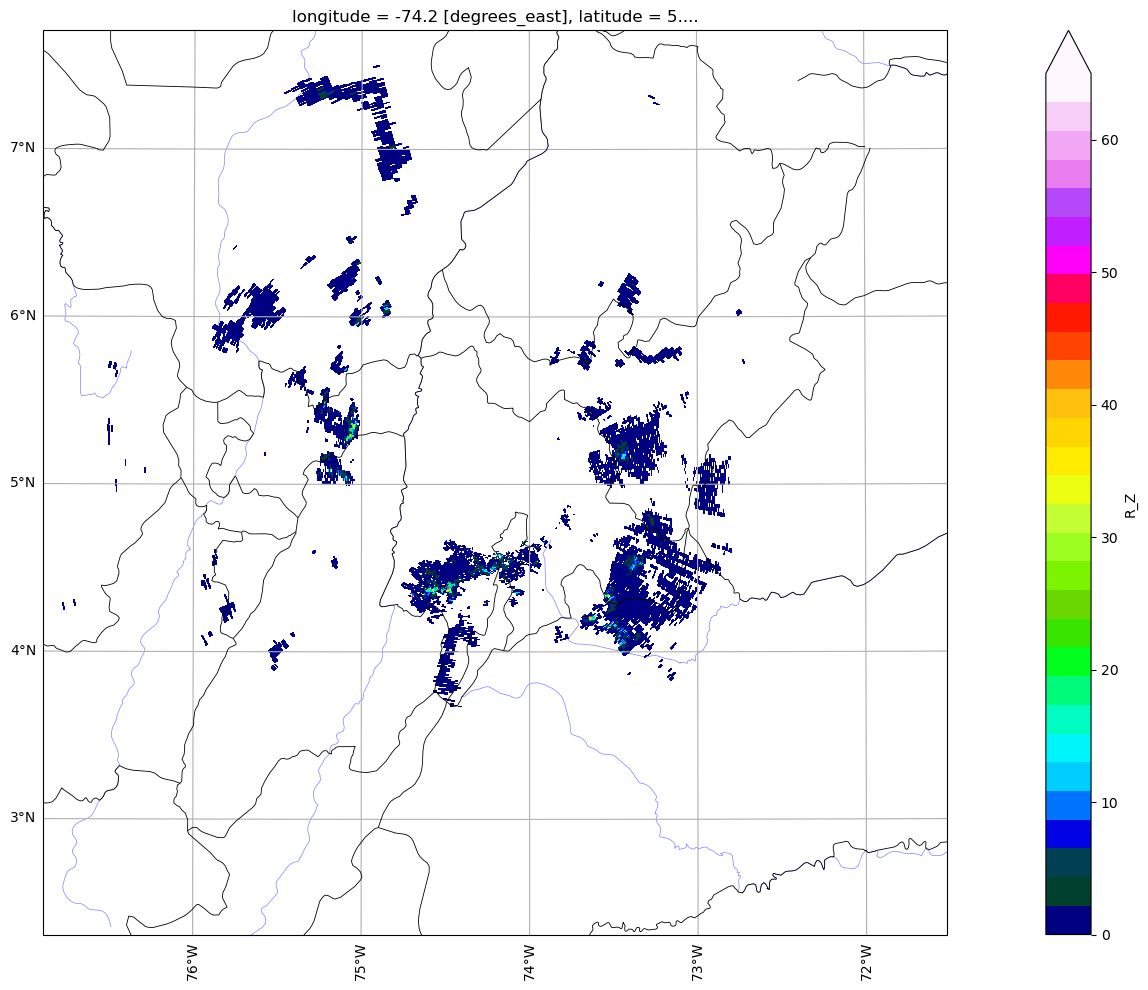

In [54]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)]):
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=65,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
plt.tight_layout()

In [55]:
lat = dtree.latitude.values
lon = dtree.longitude.values
max_range = swp.range.values[-1]/1e3/111

max_lat = lat + max_range
max_lon = lon + max_range
min_lat = lat - max_range
min_lon = lon - max_range

In [56]:
from sodapy import Socrata
import datetime as dt
import pandas as pd

TOKEN = ""

def download_data(date_init: dt.datetime, date_end: dt.datetime) -> pd.DataFrame:
    client = Socrata("www.datos.gov.co", TOKEN)

    date_init = pd.Timestamp(date_init).tz_localize('UTC').tz_convert('America/Bogota')
    date_end  = pd.Timestamp(date_end).tz_localize('UTC').tz_convert('America/Bogota')

    query = client.get(
        dataset_identifier = "s54a-sgyg",
        select             = "codigoestacion, fechaobservacion, latitud, longitud, valorobservado, unidadmedida",
        where              = f"fechaobservacion >= '{date_init.strftime('%Y-%m-%d')}' AND fechaobservacion < '{date_end.strftime('%Y-%m-%d')}'"
                             f"AND latitud > '{min_lat}' AND latitud < '{max_lat}' AND longitud > '{min_lon}' AND longitud < '{max_lon}'",
        limit              = 50000000,
    )

    data = pd.DataFrame.from_records(query)

    return data

In [57]:
time_str = dtree["time_coverage_start"].values
#time_str = time_arr.item().decode('utf-8')
time_pd = pd.to_datetime(time_str)  

start_utc = time_pd - pd.Timedelta(minutes=9)
end_utc   = time_pd + pd.Timedelta(minutes=1)
print(start_utc)
print(end_utc)

df = download_data(dt.datetime(time_pd.year,
                               time_pd.month,
                               time_pd.day),
                   dt.datetime(time_pd.year,
                               time_pd.month,
                               time_pd.day +1+1)) # a dia 12/05/2026 no funciona del tot correctament i has de posar un dia més perquè et retorni el dia que pertoca
print(df)

2024-10-21 23:36:30+00:00
2024-10-21 23:46:30+00:00
       codigoestacion         fechaobservacion      latitud       longitud  \
0          2120500201  2024-10-20T00:00:00.000      4.57515      -74.07175   
1          0021206780  2024-10-20T00:00:00.000     4.619272     -74.194594   
2          2120000100  2024-10-20T00:00:00.000     4.652389     -74.075434   
3          3502500135  2024-10-20T00:00:00.000      4.22553      -73.81481   
4          0026085160  2024-10-20T00:00:00.000       3.4255   -76.56061111   
...               ...                      ...          ...            ...   
184171     2403000117  2024-10-21T21:04:00.000  6.447166667  -72.497694444   
184172     0026125710  2024-10-21T21:04:00.000     4.812675  -75.739519444   
184173     0024035340  2024-10-21T21:04:00.000  5.676944444   -72.96791667   
184174     0024035340  2024-10-21T21:06:00.000  5.676944444   -72.96791667   
184175     0024035340  2024-10-21T21:06:00.000  5.676944444   -72.96791667   

       valo

In [58]:
df["fechaobservacion"] = (
    pd.to_datetime(df["fechaobservacion"])
    .dt.tz_localize("America/Bogota")
    .dt.tz_convert("UTC")
)
print(df)

       codigoestacion          fechaobservacion      latitud       longitud  \
0          2120500201 2024-10-20 05:00:00+00:00      4.57515      -74.07175   
1          0021206780 2024-10-20 05:00:00+00:00     4.619272     -74.194594   
2          2120000100 2024-10-20 05:00:00+00:00     4.652389     -74.075434   
3          3502500135 2024-10-20 05:00:00+00:00      4.22553      -73.81481   
4          0026085160 2024-10-20 05:00:00+00:00       3.4255   -76.56061111   
...               ...                       ...          ...            ...   
184171     2403000117 2024-10-22 02:04:00+00:00  6.447166667  -72.497694444   
184172     0026125710 2024-10-22 02:04:00+00:00     4.812675  -75.739519444   
184173     0024035340 2024-10-22 02:04:00+00:00  5.676944444   -72.96791667   
184174     0024035340 2024-10-22 02:06:00+00:00  5.676944444   -72.96791667   
184175     0024035340 2024-10-22 02:06:00+00:00  5.676944444   -72.96791667   

       valorobservado unidadmedida  
0             

In [59]:
utc_start = pd.Timestamp(f"{start_utc.year}-{start_utc.month}-{start_utc.day}", tz="UTC") 
utc_end   = pd.Timestamp(f"{start_utc.year}-{start_utc.month}-{start_utc.day + 1}", tz="UTC")
print(utc_start)
print(utc_end)
print(start_utc)

date_filtered_df = df[df["fechaobservacion"].between(utc_start, utc_end)]

#for fecha in date_filtered_df["fechaobservacion"].values:
#    print(fecha)
print(date_filtered_df)

time_utc_start = pd.Timestamp(f"{start_utc.hour}:{start_utc.minute}:00", tz="UTC").time()
time_utc_end   = pd.Timestamp(f"{end_utc.hour}:{end_utc.minute}:00", tz="UTC").time()
time_filtered_df = date_filtered_df[date_filtered_df["fechaobservacion"].dt.time.between(time_utc_start, time_utc_end)]

print(time_filtered_df)

2024-10-21 00:00:00+00:00
2024-10-22 00:00:00+00:00
2024-10-21 23:36:30+00:00
       codigoestacion          fechaobservacion      latitud       longitud  \
119042     0035197030 2024-10-21 00:00:00+00:00  5.179694444  -72.568388889   
119043     3502500135 2024-10-21 00:00:00+00:00      4.22553      -73.81481   
119044     0035217010 2024-10-21 00:00:00+00:00        5.369   -72.41372222   
119045     0021208480 2024-10-21 00:00:00+00:00   4.61104201     -74.178333   
119046     0021185080 2024-10-21 00:00:00+00:00  4.216458333  -75.104611111   
...               ...                       ...          ...            ...   
183765     0021185080 2024-10-22 00:00:00+00:00  4.216458333  -75.104611111   
183766     0022070030 2024-10-22 00:00:00+00:00  4.124555556   -75.49952778   
183767     0023085270 2024-10-22 00:00:00+00:00    6.1686111  -75.426111111   
183768     0021227010 2024-10-22 00:00:00+00:00     4.535225  -74.880530556   
183769     0023085270 2024-10-22 00:00:00+00:00    6.

In [60]:
filtered_df = time_filtered_df

In [61]:
print(np.unique_counts(filtered_df["codigoestacion"]))

UniqueCountsResult(values=array(['0021185080', '0021227010', '0022070030', '0023085270',
       '0023195502', '0024035340', '0026075150', '0026085160',
       '0026125061', '0026125710', '0026155110', '0026237040',
       '0027015330'], dtype=object), counts=array([ 2,  2,  2,  2, 14, 10, 12,  2, 12, 12,  2,  2,  2]))


In [62]:
filtered_df["valorobservado"] = pd.to_numeric(filtered_df["valorobservado"].astype(float)*6, errors="coerce")
df = df.dropna(subset=["valorobservado"])

filtered_df["latitud"] = pd.to_numeric(filtered_df["latitud"], errors="coerce")
df = df.dropna(subset=["latitud"])

filtered_df["longitud"] = pd.to_numeric(filtered_df["longitud"], errors="coerce")
df = df.dropna(subset=["longitud"])

print(filtered_df)

       codigoestacion          fechaobservacion   latitud   longitud  \
183626     0026125061 2024-10-21 23:36:00+00:00  4.454722 -75.766389   
183627     0027015330 2024-10-21 23:36:00+00:00  6.224679 -75.588225   
183628     0026075150 2024-10-21 23:36:00+00:00  3.532992 -76.382500   
183629     0023195502 2024-10-21 23:36:00+00:00  7.121472 -73.184528   
183630     0026125710 2024-10-21 23:36:00+00:00  4.812675 -75.739519   
...               ...                       ...       ...        ...   
183697     0024035340 2024-10-21 23:46:00+00:00  5.676944 -72.967917   
183698     0026125061 2024-10-21 23:46:00+00:00  4.454722 -75.766389   
183699     0026075150 2024-10-21 23:46:00+00:00  3.532992 -76.382500   
183700     0026125710 2024-10-21 23:46:00+00:00  4.812675 -75.739519   
183701     0023195502 2024-10-21 23:46:00+00:00  7.121472 -73.184528   

        valorobservado unidadmedida  
183626           0.174           mm  
183627           0.000           mm  
183628           0.00

In [63]:
var="R_A"
number_of_colors=25

<xarray.DataArray 'R_A' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.06042 1.041 2.057 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2024-10-21T23:45:45.515000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 ... 1.139e+04
    longitude       float64 8B -74.2
    latitude        float64 8B 5.012
    altitud

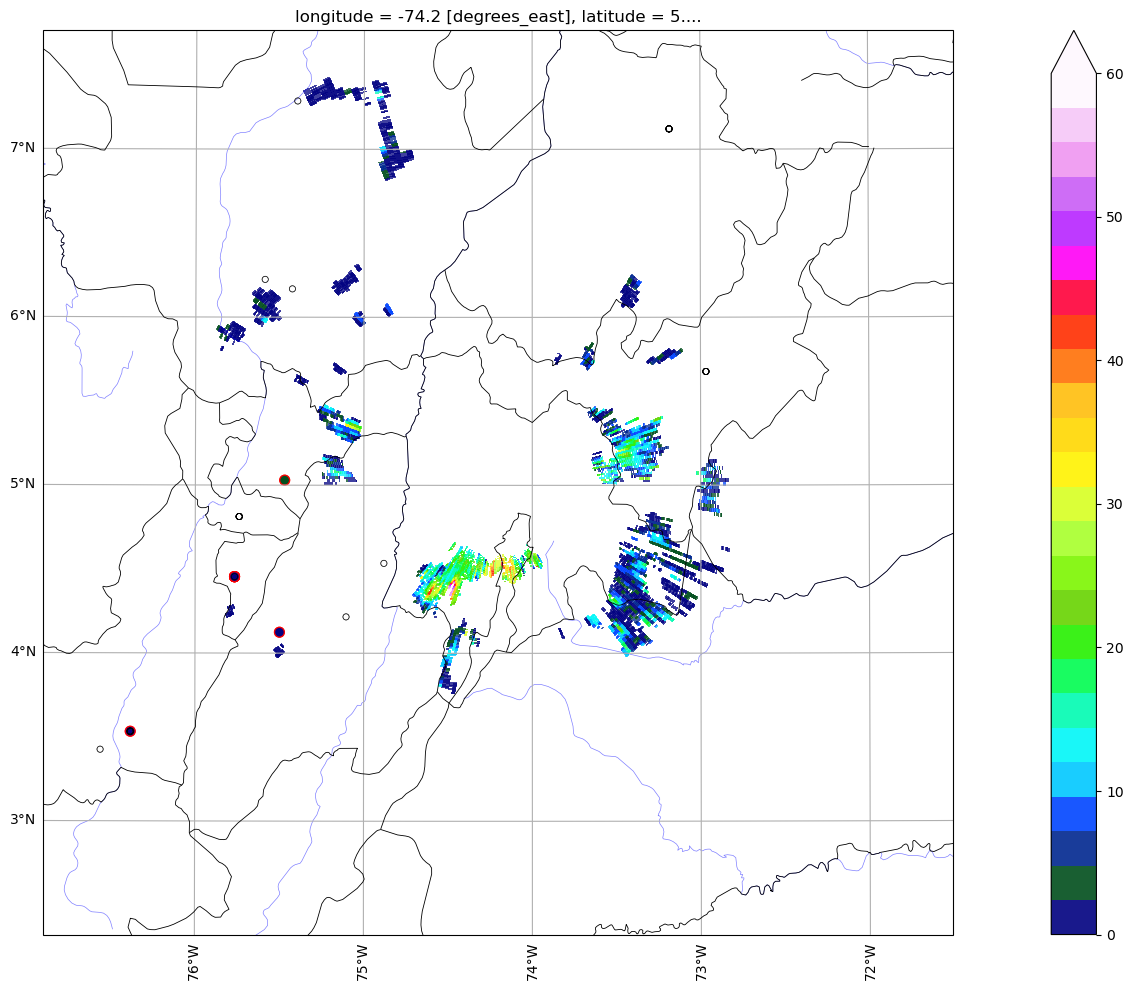

In [64]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
    alpha=0.75
)

filtered_df = filtered_df.dropna(subset=["longitud", "latitud", "valorobservado"])

print(f"Plotting {len(filtered_df)} points")
print(f"Lon range: {filtered_df['longitud'].min():.4f} to {filtered_df['longitud'].max():.4f}")
print(f"Lat range: {filtered_df['latitud'].min():.4f} to {filtered_df['latitud'].max():.4f}")

# ---- Center projection on the data ----
center_lon = filtered_df["longitud"].mean()
center_lat = filtered_df["latitud"].mean()

# ---- Map features ----
department_lines = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    edgecolor='black',
    facecolor='never',
    linewidth=0.6
)

# ---- Separar según valor observado ----
zeros = filtered_df[filtered_df["valorobservado"] == 0]
nonzeros = filtered_df[filtered_df["valorobservado"] > 0]
print(zeros)

# ---- Dibujar puntos con precipitación >0 (relleno con colormap) ----
sc = ax.scatter(
    nonzeros["longitud"],
    nonzeros["latitud"],
    c=nonzeros["valorobservado"],
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    s=50,
    edgecolors="red",
    linewidth=0.9,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    zorder=1,
)

# ---- Dibujar puntos con valor == 0 (solo borde, sin relleno) ----
ax.scatter(
    zeros["longitud"],
    zeros["latitud"],
    facecolors="none",
    edgecolors="black",
    s=20,
    linewidth=0.5,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

cb = plt.colorbar(sc,ax=ax,extend="max")

# ---- Adjust map extent to data bounds with a small margin ----
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

In [65]:
print(dtree.longitude)
print(dtree.latitude)
print(swp.range.values[1]-swp.range.values[0])


gauge_lats = df["latitud"].values
gauge_lons = df["longitud"].values

<xarray.DataArray 'longitude' ()> Size: 8B
array(-74.20369998)
Attributes:
    long_name:      longitude
    units:          degrees_east
    standard_name:  longitude
<xarray.DataArray 'latitude' ()> Size: 8B
array(5.01180008)
Attributes:
    long_name:      latitude
    units:          degrees_north
    positive:       up
    standard_name:  latitude
450.0


In [66]:
lon_gauge = filtered_df["longitud"].values
lat_gauge = filtered_df["latitud"].values

print(lon_gauge,lat_gauge)

[-75.76638889 -75.588225   -76.3825     -73.18452778 -75.73951944
 -75.76638889 -75.588225   -76.3825     -73.18452778 -75.73951944
 -73.18452778 -75.76638889 -75.73951944 -72.96791667 -76.3825
 -73.18452778 -75.76638889 -75.73951944 -72.96791667 -76.3825
 -75.46991667 -76.56061111 -72.96791667 -75.396725   -75.73951944
 -76.3825     -75.49952778 -75.76638889 -73.18452778 -75.42611111
 -73.18452778 -74.88053056 -75.10461111 -75.46991667 -76.56061111
 -72.96791667 -75.396725   -75.73951944 -76.3825     -75.49952778
 -75.76638889 -73.18452778 -75.42611111 -73.18452778 -74.88053056
 -75.10461111 -76.3825     -75.73951944 -75.76638889 -73.18452778
 -72.96791667 -76.3825     -75.73951944 -75.76638889 -73.18452778
 -72.96791667 -73.18452778 -75.73951944 -72.96791667 -76.3825
 -75.76638889 -73.18452778 -75.73951944 -72.96791667 -76.3825
 -75.76638889 -72.96791667 -75.76638889 -76.3825     -75.73951944
 -73.18452778 -72.96791667 -75.76638889 -76.3825     -75.73951944
 -73.18452778] [4.45472222

In [67]:
gate_lon = swp['gate_longitude'].values
gate_lat = swp['gate_latitude'].values 

radar_precip = swp['R_A'].values

In [68]:
gate_points = np.column_stack([gate_lon.ravel(), gate_lat.ravel()])
tree = cKDTree(gate_points)

gauge_coords = filtered_df[['longitud', 'latitud']].values
distances, indices = tree.query(gauge_coords, k=1)

n_az = gate_lon.shape[0]
n_rng = gate_lon.shape[1]
az_idx = indices // n_rng
rng_idx = indices % n_rng

In [69]:
radar_vals = radar_precip[az_idx, rng_idx]

radar_vals = radar_precip[az_idx, rng_idx]

# Add to station dataframe
filtered_df['radar_precip'] = radar_vals
filtered_df['distance_to_radar_gate_m'] = distances 

In [70]:
# e.g., discard stations farther than 1 km from nearest gate (adjust threshold)
filtered_df = filtered_df[filtered_df['distance_to_radar_gate_m'] < 240000] 

/tmp/ipykernel_6352/3766909635.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


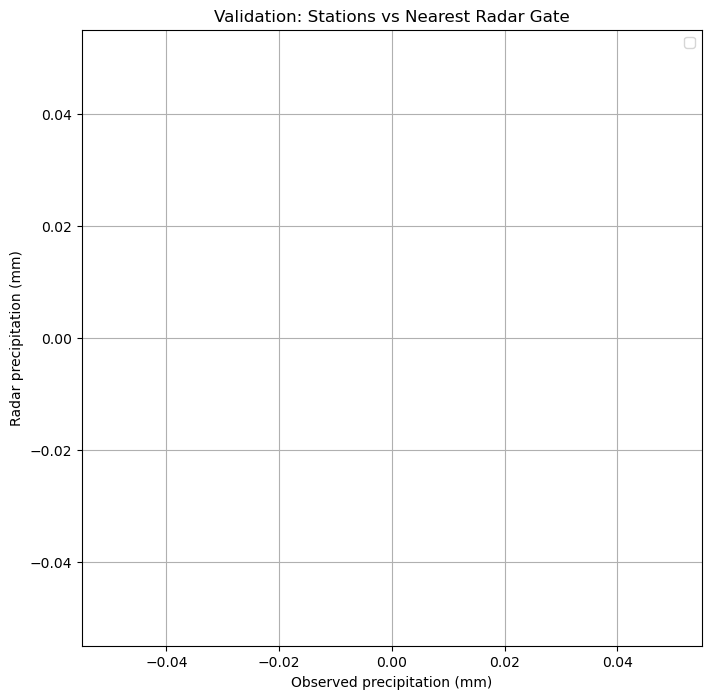

In [466]:
# Keep rows where both are > 0 (or >= some threshold)
#rain = df_obs[(df_obs['valorobservado'] > 0) & (df_obs['radar_precip'] > 0)]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(filtered_df['valorobservado'], filtered_df['radar_precip'], alpha=0.6, edgecolors='k')
#max_val = max(filtered_df['valorobservado'].max(), filtered_df['radar_precip'].max())
#ax.plot([0, max_val], [0, max_val], 'r--', label='1:1 line')
ax.set_xlabel('Observed precipitation (mm)')
ax.set_ylabel('Radar precipitation (mm)')
ax.set_title('Validation: Stations vs Nearest Radar Gate')
ax.grid(True)
ax.legend()
plt.show()

In [467]:
print(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2024-10-21T23:45:30Z'
│       time_coverage_end    <U20 80B '2024-10-21T23:45:54Z'
│       longitude            float64 8B -74.2
│       altitude             float64 8B 3.544e+03
│       latitude             float64 8B 5.012
│       sweep_fixed_angle    (sweep) float64 8B 0.5
│       sweep_group_name     (sweep) int64 8B 1
│   Attributes:
│       Conventions:      None
│       instrument_name:  Tablazo, Radar
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet
│       history:          None
│       comment:          AEROCIVIL OPERATIONAL DUAL POLE SCAN
│       scan_name:        SURV_HV_300 

[ 3546.62324969  3550.5779581   3554.55646715  3558.55877679
  3562.58488699  3566.63479772  3570.70850894  3574.80602063
  3578.92733274  3583.07244524  3587.2413581   3591.43407127
  3595.65058474  3599.89089845  3604.15501238  3608.44292649
  3612.75464074  3617.0901551   3621.44946953  3625.83258376
  3630.23949846  3634.67021265  3639.12472723  3643.60304122
  3648.10515554  3652.63106919  3657.18078309  3661.75429625
  3666.35160958  3670.9727221   3675.6176347   3680.28634641
  3684.97885814  3689.69516889  3694.43527958  3699.19918921
  3703.98689776  3708.79840706  3713.63371519  3718.49282212
  3723.37572779  3728.28243405  3733.21293898  3738.16724253
  3743.14534467  3748.14724723  3753.17294829  3758.22244781
  3763.29574575  3768.39284394  3773.51374047  3778.65843528
  3783.82692833  3789.01922335  3794.23531276  3799.47520405
  3804.73888965  3810.02637703  3815.3376624   3820.6727457
  3826.0316269   3831.4143097   3836.82078655  3842.25106491
  3847.70513722  3853.183

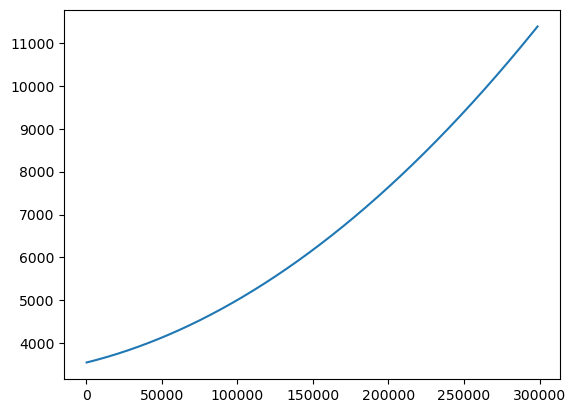

In [468]:
print(swp.isel(azimuth=0)["gate_height"].values)
print(swp.isel(azimuth=0)["range"].values)

plt.plot(swp.isel(azimuth=0)["range"].values, swp.isel(azimuth=0)["gate_height"].values)
plt.show()

In [469]:
import pysoundings

stnm, year, month, day_hour = '80222', '2024', '10', '2112'
data, units = pysoundings.get_data(stnm, year, month, day_hour)
print(data)



ModuleNotFoundError: No module named 'pysoundings'